# 02 — Data Annotation

## Data file

This notebook annotates raw Reddit JSON files (produced by `01_data_download.ipynb`) and builds the base comments dataset. Annotation adds topic classification, delta labeling, and evidence detection to the raw data — see Section 1 below.

Raw files are not stored in this repository due to size. Download the raw data file from Google Drive (read-only link, no sign-in required):

**[Google Drive — raw data file](https://drive.google.com/file/d/1KMfiMTJ8_bOg2efccsjTsgk-LNj_-FTg/view?usp=sharing)**

Place it under `data/` as follows:
```
data/
└── 20250210005631_posts.zip
```

> **Skipping this notebook?** If you only want to re-run the analysis, start from
> `03_feature_engineering.ipynb` — the output of this notebook is already saved in
> `results/comments_df_base.csv`.


In [1]:
# Local path config — adjust if your data lives elsewhere
import os
import json
import zipfile
DATA_DIR  = os.path.abspath('../data')
RESULTS_DIR = os.path.abspath('../results')
print('DATA_DIR :', DATA_DIR)
print('RESULTS_DIR:', RESULTS_DIR)


DATA_DIR : /Users/dikla/Documents/Private/study/change-my-view-2025/data
RESULTS_DIR: /Users/dikla/Documents/Private/study/change-my-view-2025/results


# １. Annotation Pipeline

Raw JSON files downloaded by `01_data_download.ipynb` are stored in `data/`. The annotation step below runs automatically on any file that does not yet have an annotated counterpart in `data/annotated/`. Already-annotated files are skipped.


For each raw JSON in `data/`, this step applies topic classification, delta labeling, and evidence detection. Keyword files are loaded from `data/topics/` and `data/evidence-language/`; if absent, those two annotation types are skipped and only delta labeling runs.

In [2]:
# Based on discussion_analysis.py by J. Hunter Priniski & Zachary Horne
# https://github.com/jpriniski/CMV
import itertools, string, re
from bs4 import BeautifulSoup
from nltk.stem.snowball import SnowballStemmer

_stemmer = SnowballStemmer('english')

def _read_terms(path):
    with open(path) as f:
        lines = [l.strip() for l in f.read().split('\n') if l.strip()]
    stemmed = [[_stemmer.stem(t) for t in line.split()] for line in lines]
    stemmed.sort()
    return list(s for s, _ in itertools.groupby(stemmed))

def _prepare(text):
    table = str.maketrans("", "", string.punctuation)
    tokens = [_stemmer.stem(w) for w in text.lower().translate(table).split()]
    tokens.sort()
    return list(t for t, _ in itertools.groupby(tokens))

def _get_ngrams(text, n):
    if n == 1:
        return [[w] for w in text]
    return [list(g) for g in zip(*[text[i:] for i in range(n)])]

def _match(text, terms):
    largest = max(len(x) for x in terms)
    for i in range(1, largest + 1):
        grams = _get_ngrams(text, i)
        for term in terms:
            if term in grams:
                return True
    return False

def _classify_text(text, categories):
    prepared = _prepare(text)
    result = {}
    for key, terms in categories.items():
        result[key] = {'match': _match(prepared, terms)}
        if 'number' in key.lower() and any(c.isdigit() for c in text):
            result[key]['match'] = True
    return result

def _get_parent(comments, current):
    parent_id = current['parent_id']
    for c in comments:
        if parent_id in c.get('name', ''):
            return c
    return None

def _award_deltas(comments):
    delta_ids = {
        c['id'] for c in comments
        if c.get('author') and 'DeltaBot' in c['author']
        and 'confirmed: 1 delta awarded to' in c.get('body', '').lower()
    }
    for c in comments:
        c['Delta'] = {'count': 0, 'from': {}}
    for c in comments:
        if c['id'] in delta_ids:
            delta_sig = _get_parent(comments, c)
            if delta_sig is None:
                continue
            dac = _get_parent(comments, delta_sig)
            if dac is None:
                continue
            dac['Delta']['count'] += 1
            if 'author' in delta_sig:
                dac['Delta']['from'][delta_sig['author']] = delta_sig.get('body', '')

def _get_links(comments):
    for c in comments:
        if 'body_html' not in c:
            continue
        soup = BeautifulSoup(c['body_html'], 'html.parser')
        c['links'] = [str(a) for a in soup.findAll('a', attrs={'href': re.compile("^https?://")})]


In [3]:
TOPICS_DIR   = os.path.abspath('../data/topics')
EVIDENCE_DIR = os.path.abspath('../data/evidence-language')
ANNOTATED_DIR = os.path.join(DATA_DIR, 'annotated')

def _load_categories(base_dir, names):
    if not os.path.isdir(base_dir):
        return None
    cats = {n: _read_terms(os.path.join(base_dir, f'{n}.txt'))
            for n in names if os.path.exists(os.path.join(base_dir, f'{n}.txt'))}
    return cats or None

def _load_raw(path):
    if path.endswith('.zip'):
        with zipfile.ZipFile(path) as zf:
            with zf.open(zf.namelist()[0]) as f:
                return json.load(f)
    with open(path) as f:
        return json.load(f)

topics   = _load_categories(TOPICS_DIR,   ['gender', 'hot_topics', 'lgbt', 'moral', 'politics', 'race', 'religion'])
evidence = _load_categories(EVIDENCE_DIR, ['data', 'economics', 'evidence', 'numbers', 'stats', 'values', 'explanations'])

os.makedirs(ANNOTATED_DIR, exist_ok=True)
annotated = []

for fname in sorted(os.listdir(DATA_DIR)):
    if not (fname.endswith('.json') or fname.endswith('.zip')):
        continue
    annotated_fname = fname if fname.endswith('.json') else fname[:-4] + '.json'
    annotated_path = os.path.join(ANNOTATED_DIR, annotated_fname)
    if os.path.exists(annotated_path):
        print(f'Already annotated — skipping {fname}')
        continue
    data = _load_raw(os.path.join(DATA_DIR, fname))
    for post in data:
        if not post.get('selftext'):
            continue
        if topics:
            post['topic'] = _classify_text(post['title'] + ' ' + post['selftext'], topics)
        if not post.get('_comments'):
            continue
        _get_links(post['_comments'])
        _award_deltas(post['_comments'])
        if evidence:
            for comment in post['_comments']:
                if 'body' in comment:
                    comment['evidence_use'] = _classify_text(comment['body'], evidence)
    with open(annotated_path, 'w') as f:
        json.dump(data, f)
    print(f'Annotated → {annotated_path}')
    annotated.append(fname)

if not annotated:
    print('No new files to annotate.')
if not topics:
    print(f'\nNote: topic/evidence keyword files not found at {TOPICS_DIR}/')
    print('Topic and evidence classification were skipped.')
    print('To enable, add the .txt files from https://github.com/jpriniski/CMV/tree/master/Study2')


/var/folders/_0/fw_khfx97rs1j2m2d2xx1x400000gp/T/ipykernel_8451/773897277.py:77: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  c['links'] = [str(a) for a in soup.findAll('a', attrs={'href': re.compile("^https?://")})]


Annotated → /Users/dikla/Documents/Private/study/change-my-view-2025/data/annotated/20250210005631_posts.json


In [4]:
import pandas as pd
import glob

annotated_files = sorted(glob.glob(os.path.join(ANNOTATED_DIR, '*.json')))
posts = []
for path in annotated_files:
    with open(path) as f:
        posts.extend(json.load(f))

df = pd.DataFrame(posts)
print(f'{len(df)} posts loaded from {len(annotated_files)} file(s)')


425 posts loaded from 1 file(s)


This is our dataset — 425 posts from the r/changemyview subreddit.

# ２. Data Structure

In [5]:
df.columns

Index(['selftext', 'gilded', 'title', 'subreddit_name_prefixed', 'pwls',
       'link_flair_css_class', 'name', 'subreddit_type', 'ups', 'domain',
       'link_flair_text', 'score', 'is_self', 'created', 'link_flair_type',
       'wls', 'author_flair_type', 'selftext_html', 'suggested_sort',
       'archived', 'is_crosspostable', 'subreddit_id', 'id', 'author',
       'num_crossposts', 'num_comments', 'send_replies', 'permalink', 'url',
       'subreddit_subscribers', 'created_utc', 'comment_limit', 'comment_sort',
       '_comments', 'topic', 'edited', 'locked', 'link_flair_text_color',
       'link_flair_template_id', 'author_flair_text',
       'link_flair_background_color', 'author_flair_text_color',
       'author_flair_css_class', 'over_18', 'is_reddit_media_domain'],
      dtype='str')

Each row is one Reddit thread. Key post-level fields: `id`, `title`, `selftext` (post body), `author`.

Comments are stored in `_comments`. Each comment carries the annotation fields used downstream:

| Field | Description |
|-------|-------------|
| `body` | Comment text |
| `Delta` | `True` if this comment earned a delta (i.e., changed OP's view) |
| `evidence_use` | Evidence language annotation |
| `parent_id` | ID of the parent post or comment (determines tree structure) |

In [6]:
# Sample posts
df[['id', 'title', 'author']].head(3)

,id,title,author
0,fdziov,CMV: Mike Bloomberg's campaign is proof that t...,boss_454
1,hlpd7d,CMV: Kanye West is a shill for president Trump...,Psyworld
2,mzr23d,CMV: Most Americans who oppose a national heal...,CrashRiot


In [7]:
# Sample comment — all annotation fields visible
df.iloc[0]['_comments'][0]

{'subreddit_id': 't5_2w2s8',
 'ups': 527,
 'link_id': 't3_fdziov',
 'author_flair_type': 'text',
 'id': 'fjl6e6m',
 'gilded': 1,
 'archived': True,
 'author': 'A_Soporific',
 'send_replies': True,
 'parent_id': 't3_fdziov',
 'score': 527,
 'body': 'No one espouses "trickle down", the term was coined as a dig at Hoover\'s engineering degree. The joke being that he knows that water trickles down but he doesn\'t realize that money trickles up. The whole thing has been a dig for a century and doesn\'t really have theoretical defense since it is a straw man position designed and intended to be easily attacked.\n\nThe big issues with taxes is that very often they do things that they aren\'t intended to do. Corporate taxes are a poster child for tax incidence. What is tax incidence? Well, it\'s who *really* ends up paying the tax. But, I hear you say, corporations pay the tax, they send in the check. At the end of the day, it doesn\'t matter who mails in the check it only matters who is out m

# ３. Creating the Comments Dataset

The raw data contains a row for every thread. We want to find the convincing comments and create for each of them a row that contains:
* The original post
* The convincing comment
* The context: all the previous comments in the thread that were authored by the same same author as the convincing comment
* The class = is_convincing = true
* The convincing comment id (for debugging purposes)

We will throw away any additional comments that come AFTER the convincing comment in the thead.

Then, for every "leaf" in the tree of comments, we will create an appropriate row with the same structure, and set is_convincing = false. Unless the leaf is a parent of a (removed) convincing comment.

**Note:** we chose to define the context of the comment as only the comments by the same author. We could use all the comments in the thread instead. There are pros and cons for each approach.

If we only use the comments by the same author, we may lose other comments by different authors that represent the same "side" of the argument as the author of the convincing comment, and these additional commnets may affect the overall persuasion.

However, using only the same author guarentees that the "context" will have the same writing style, sentiment and opinion as the convincing comment. The style and sentiment are important for the features that we will later create from the data.

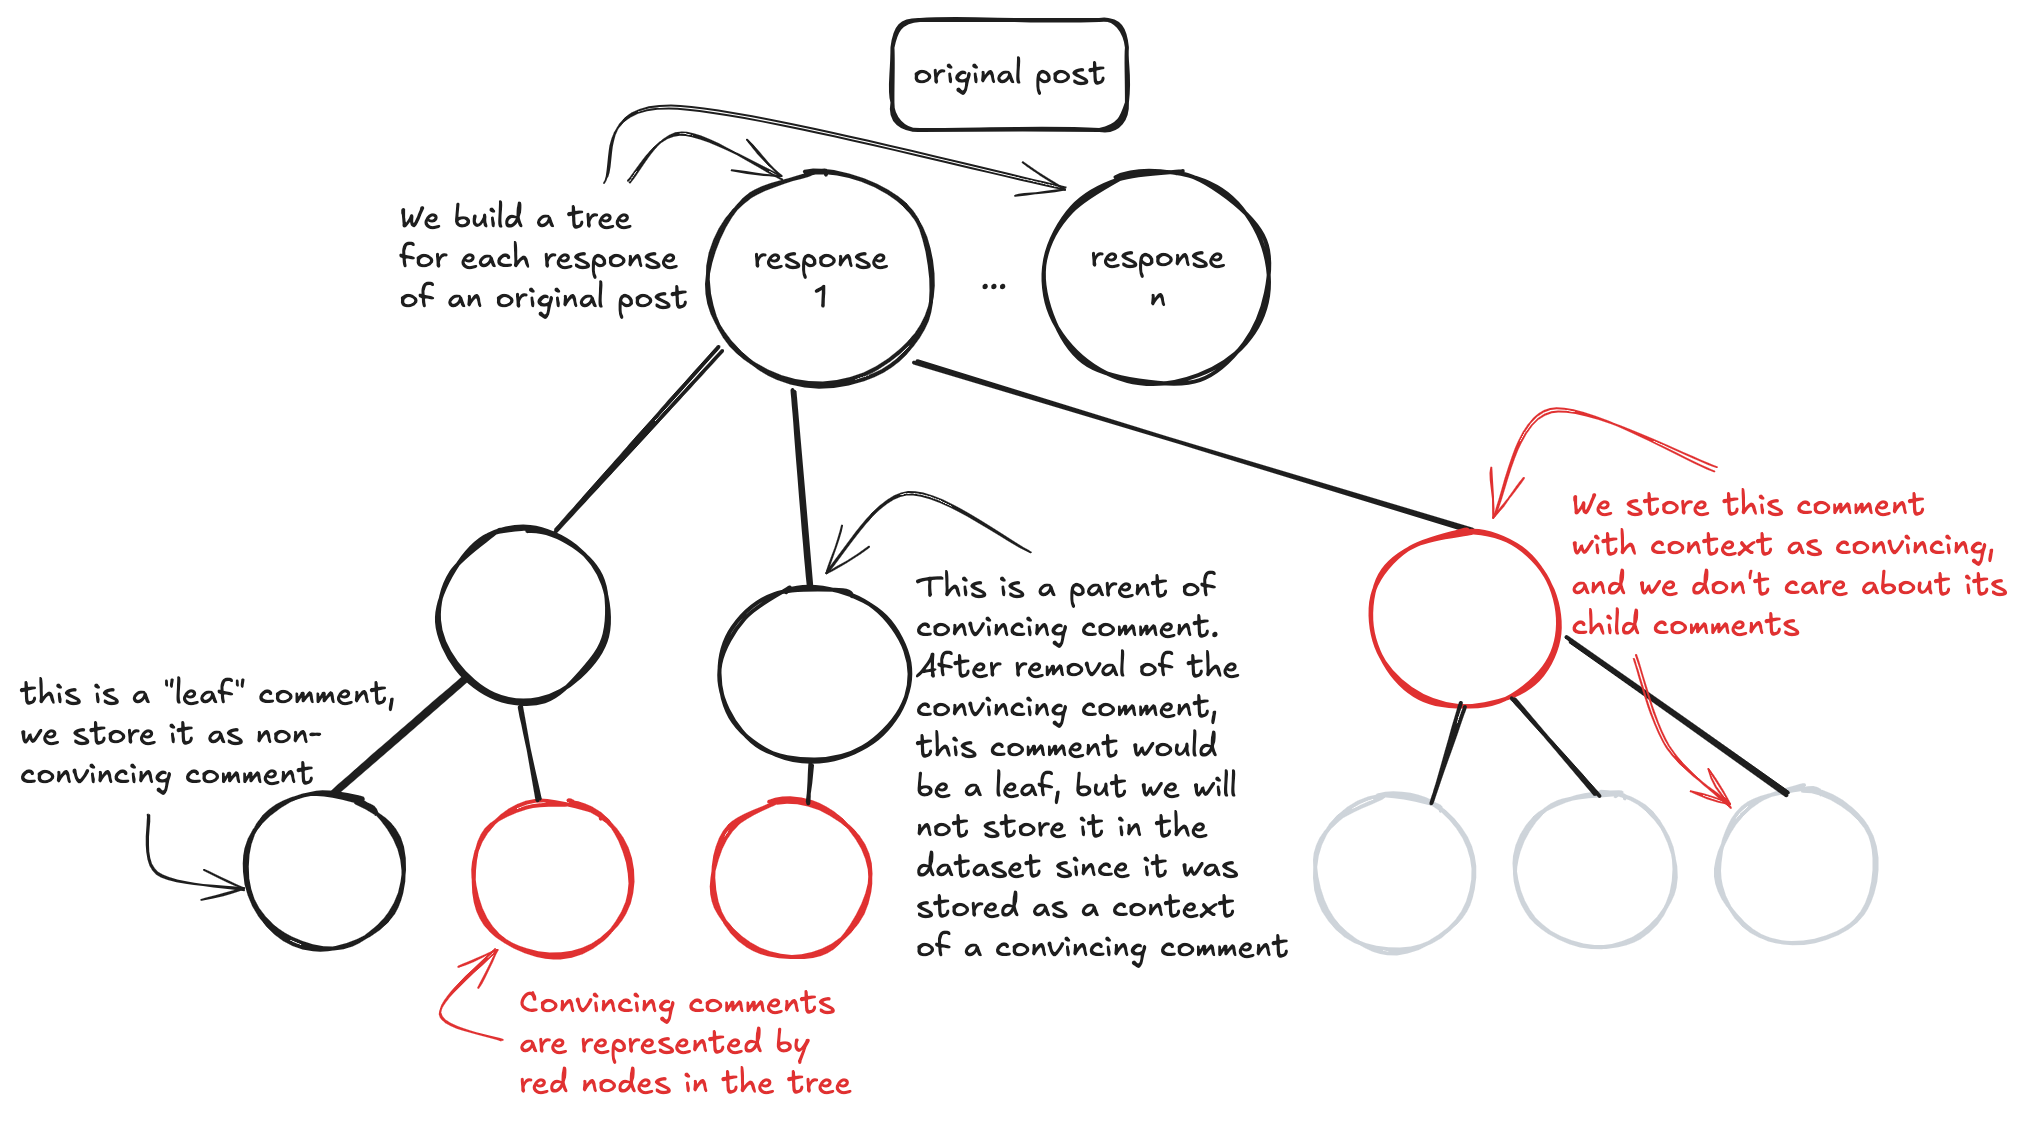

First, we will create the code to build the tree. As an example, we will work on an arbitrary row in the dataframe. Later we will use this code on all the rows in the df.

In [8]:

def add_children(comment, all_comments):
    child_comments = [com for com in all_comments if com['parent_id_edited'] == comment['id']]
    if not child_comments:
        return

    for child_comment in child_comments:
      child_comment['children'] = []
      comment['children'].append(child_comment)
      add_children(child_comment, all_comments)

def build_comment_tree(comments, original_post_id):
    comment_map = {comment['id']: comment for comment in comments}
    tree = []

    for comment in comments:
        if comment['parent_id_edited'] == original_post_id:
            comment['children'] = []
            tree.append(comment)

    for comment in tree:
        add_children(comment, comments)

    return tree

# Example usage with the comments from the first thread in the dataframe
thread = df.iloc[0]['_comments']
for comment in thread:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread, df.iloc[0]['id'])
print(json.dumps(comment_tree, indent=2))


[
  {
    "subreddit_id": "t5_2w2s8",
    "ups": 527,
    "link_id": "t3_fdziov",
    "author_flair_type": "text",
    "id": "fjl6e6m",
    "gilded": 1,
    "archived": true,
    "author": "A_Soporific",
    "send_replies": true,
    "parent_id": "t3_fdziov",
    "score": 527,
    "body": "No one espouses \"trickle down\", the term was coined as a dig at Hoover's engineering degree. The joke being that he knows that water trickles down but he doesn't realize that money trickles up. The whole thing has been a dig for a century and doesn't really have theoretical defense since it is a straw man position designed and intended to be easily attacked.\n\nThe big issues with taxes is that very often they do things that they aren't intended to do. Corporate taxes are a poster child for tax incidence. What is tax incidence? Well, it's who *really* ends up paying the tax. But, I hear you say, corporations pay the tax, they send in the check. At the end of the day, it doesn't matter who mails in 

The next step would be to travel the entire tree and find the convincing comments. For these comments we will:
1. add them to a data frame with the original post and the previous comments of the same author in the thread
2. mark their parent as parent_of_convincing = true
3. drop the comment from the tree

In [9]:
import pandas as pd
import copy

separator_token = "[SEP]"

def add_new_row(current_comment, previous_comments, original_post, is_convincing, df):
  if not current_comment.get('author') or not current_comment.get('body'): # a deleted comment, we can't add it
    return
  convincing_comment_context = ""
  if previous_comments.get(current_comment['author']):
    convincing_comment_context = f"\n{separator_token}\n".join(previous_comments[current_comment['author']])

  new_row = {'original_post': original_post, 'thread_text': convincing_comment_context, 'final_comment': current_comment['body'], 'is_convincing': is_convincing, 'final_comment_id': current_comment['id']}
  df.loc[len(df)] = new_row

def add_convincing_comments(comment_tree, convincing_comments_df, original_post, parent_comment=None, comments_in_thread = {}):
    for comment in comment_tree:
        if comment.get('Delta', {}).get('count', 0) > 0:
            add_new_row(comment, comments_in_thread, original_post, 1, convincing_comments_df)

            if parent_comment:
                parent_comment['parent_of_convincing'] = True

            comment_tree.remove(comment)

        # If the comment was convincing, we ignore its children. Otherwise, we continue recursively with the children:
        elif 'children' in comment and comment['children']:
            if not comment.get('author') or not comment.get('body'):
              continue
            if not comments_in_thread.get(comment['author']):
              comments_in_thread[comment['author']] = []
            comments_in_thread[comment['author']].append(comment['body'])

            add_convincing_comments(comment['children'], convincing_comments_df, original_post, comment, comments_in_thread)
            comments_in_thread[comment['author']].pop()

# Example usage:
row = df.iloc[4]

thread_comments = row['_comments']
for comment in thread_comments:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread_comments, row['id'])

convincing_comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame
add_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
# print(convincing_comments_df['final_comment_id'])

convincing_comments_df


,original_post,thread_text,final_comment,is_convincing,final_comment_id
0,"From what I know, Christ was essentially a rad...",,Jesus never spoke on government entitlement pr...,1,gj1pl5i
1,"From what I know, Christ was essentially a rad...",,A(nti)theist libertarian here;\n\nIt does seem...,1,gj1ie0v


In [10]:
def add_non_convincing_comments(comment_tree, convincing_comments_df, original_post, comments_in_thread = {}):
    for comment in comment_tree:
      if not comment.get('author') or not comment.get('body'):
        continue

      if not comment.get('children'): # this is a leaf
        if not comment.get('parent_of_convincing') and not comment['author'] == 'DeltaBot':
          add_new_row(comment, comments_in_thread, original_post, 0, convincing_comments_df)
          # else ignore this leaf
        return


      # else, the comment has children

      if not comments_in_thread.get(comment['author']):
        comments_in_thread[comment['author']] = []
      comments_in_thread[comment['author']].append(comment['body'])

      add_non_convincing_comments(comment['children'], convincing_comments_df, original_post, comments_in_thread)
      comments_in_thread[comment['author']].pop()

# example usage, with the same tree that we craeted before and removed the convincing comments from:
add_non_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
convincing_comments_df

,original_post,thread_text,final_comment,is_convincing,final_comment_id
0,"From what I know, Christ was essentially a rad...",,Jesus never spoke on government entitlement pr...,1,gj1pl5i
1,"From what I know, Christ was essentially a rad...",,A(nti)theist libertarian here;\n\nIt does seem...,1,gj1ie0v


In the above case, there were no leaves left.

Now we can execute this logic on all the rows, and create the final dataframe.

The final change here, is to add the post title to the original post field:

In [11]:
comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame


# Loop through all rows in the DataFrame 'df'
for index, row in df.iterrows():
    thread_comments = row['_comments']
    for comment in thread_comments:
        comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

    comment_tree = build_comment_tree(thread_comments, row['id'])

    original_post = str(row['title']) + "\n" + str(row['selftext'])

    add_convincing_comments(comment_tree, comments_df, original_post)
    add_non_convincing_comments(comment_tree, comments_df, original_post)

comments_df.head(10)


,original_post,thread_text,final_comment,is_convincing,final_comment_id
0,CMV: Mike Bloomberg's campaign is proof that t...,"> But, as long as Corporate taxes are a thing ...",Δ You're completely [right](https://smallbusin...,0,fjlpe2a
1,CMV: Mike Bloomberg's campaign is proof that t...,,> money being taxed as profit for the company...,0,fjm1dyy
2,CMV: Mike Bloomberg's campaign is proof that t...,,I saved your post it was so good. Hear hear to...,0,fjlcge6
3,CMV: Mike Bloomberg's campaign is proof that t...,,Jeff Bezos started Amazon in his garage and he...,0,fjlstp0
4,CMV: Mike Bloomberg's campaign is proof that t...,,Corporations are just empty vessels used by in...,0,fjm3sz6
5,CMV: Mike Bloomberg's campaign is proof that t...,,Plus if Jeff Bezos were to try to sell any of ...,0,fjlt9or
6,CMV: Mike Bloomberg's campaign is proof that t...,,Sure it does. And he doesn't have to sell it ...,0,fjm0rje
7,CMV: Mike Bloomberg's campaign is proof that t...,,Since 3.81 million shares of amazon are traded...,0,fjlivux
8,CMV: Mike Bloomberg's campaign is proof that t...,,> I also understand that could be tricky beca...,0,fjm1nhv
9,CMV: Mike Bloomberg's campaign is proof that t...,,">But guess what - entrepreneurships, startups,...",0,fjlarna


In [12]:
print("Size of the DataFrame:", comments_df.shape)
print("Number of entries with is_convincing = 1:", comments_df[comments_df['is_convincing'] == 1].shape[0])
print("Number of entries with is_convincing = 0:", comments_df[comments_df['is_convincing'] == 0].shape[0])


Size of the DataFrame: (3974, 5)
Number of entries with is_convincing = 1: 642
Number of entries with is_convincing = 0: 3332


Below is an example of a single row.
We separated thread_text (all the comments of the same author before the current comment), and final_comment (the current comment).

This way, when we create the features, we can decide for each feature whether to use the entire thread or just the comment itself.

In [13]:
print("*** The original post: ***")
print(comments_df.iloc[8]['original_post'])
print("-------------------------------")

print("*** The thread text: ***")
print(comments_df.iloc[8]['thread_text'])
print("-------------------------------")

print("*** The final comment: ***")
print(comments_df.iloc[8]['final_comment'])


*** The original post: ***
CMV: Mike Bloomberg's campaign is proof that the ultra wealthy in the US can afford a higher tax rate with no ill effect on them
Mike Bloomberg recently dropped out of the 2020 Presidential race after spending over $500 million dollars of his own money on his campaign. Even with this loss, he is still worth over $55 billion dollars.


I believe that this effortless spending on Bloombergs part showcases the reality that is wealth inequality between the ultra rich and working class. While I do not believe the rich should give up their fortunes, I do believe that any arguments against taxing them more is simply propaganda from those who hold the wealth and higher power at this point. 

Certain media outlets claim that taxing the super wealthy is unfair and would be detrimental to those below them due to "trickle down" effects. There is also rhetoric that many self made billionaires worked hard for their fortunes, and that if we as Americans work hard, we might b

Finally, let's create a "clean" version of the text fields:

In [14]:
import re

def clean_text(text):
  text = str(text)
  # Remove single digits
  text = re.sub(r'\b\d\b', '', text)
  # Remove punctuation characters
  text = re.sub(r'[^\w\s]', '', text)
  # Remove single letters
  text = re.sub(r'\b[a-zA-Z]\b', '', text)
  # Remove URLs:
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  return text

comments_df['cleaned_final_comment'] = comments_df['final_comment'].apply(clean_text)
comments_df['cleaned_thread_text'] = comments_df['thread_text'].apply(clean_text)
comments_df['cleaned_original_post'] = comments_df['original_post'].apply(clean_text)


In [15]:
# Save comments_df for use by notebook 03
comments_df.to_csv('../results/comments_df_base.csv', index=False)
print(f'Saved {len(comments_df)} rows to results/comments_df_base.csv')


Saved 3974 rows to results/comments_df_base.csv
